# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

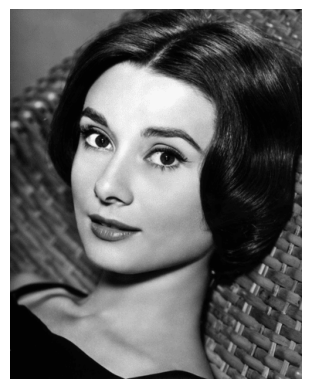

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open('C:/Users/fedaa/Desktop/imagee.png')
plt.imshow(img)
plt.axis('off')


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print("Original size:", width, height)

# scaling factors
scale = 2
new_size = (width * scale, height * scale)
print("New size:", new_size)


Original size: 378 479
New size: (756, 958)


(np.float64(-0.5), np.float64(755.5), np.float64(957.5), np.float64(-0.5))

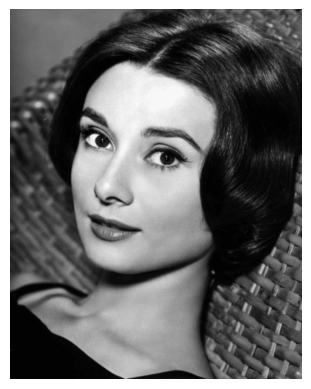

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
resized = img.resize(new_size)
plt.imshow(resized)
plt.axis('off')



In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
resized = resized.convert("RGB")
resized.save("task1_1_scaled.jpg")

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

(np.float64(-0.5), np.float64(755.5), np.float64(478.5), np.float64(-0.5))

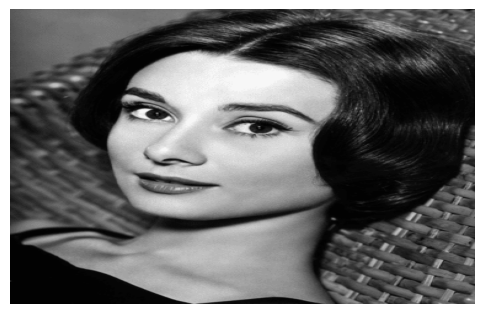

In [6]:
# non-uniform scale (stretch horizontally)

new_size2 = (width * 2, height)   

stretched = img.resize(new_size2)

plt.figure(figsize=(6,6))
plt.imshow(stretched)
plt.axis('off')

In [7]:
stretched = stretched.convert("RGB")
stretched.save("task1_1_stretched.jpg")

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

(np.float64(-0.5), np.float64(603.5), np.float64(566.5), np.float64(-0.5))

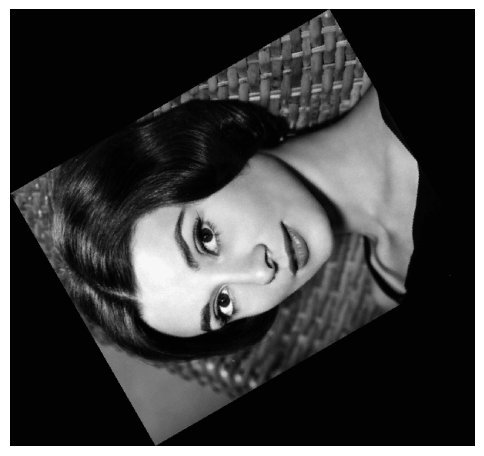

In [8]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated = img.rotate(120, expand=True)

plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.axis('off')


In [9]:
rotated = rotated.convert("RGB")
rotated.save("task1_2_rotated.jpg")

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_matrix = (1, 0.5, 0, 0, 1, 0)


(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

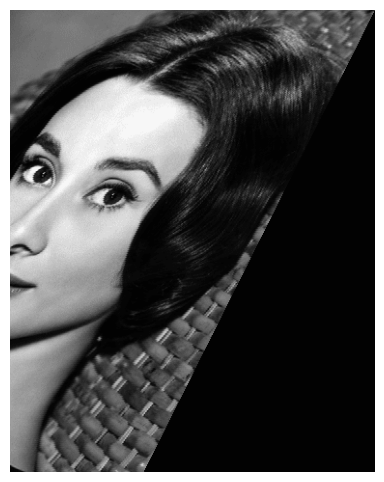

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared = img.transform(
    (width, height),
    Image.AFFINE,
    shear_matrix
)

plt.figure(figsize=(6,6))
plt.imshow(sheared)
plt.axis('off')


In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared = sheared.convert("RGB")
sheared.save("task1_3_sheared.jpg")


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

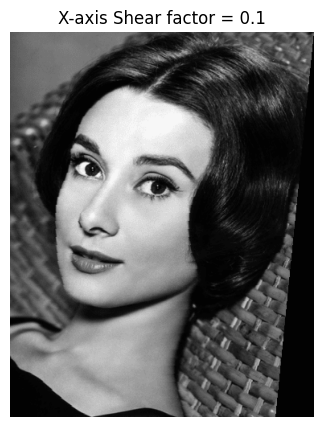

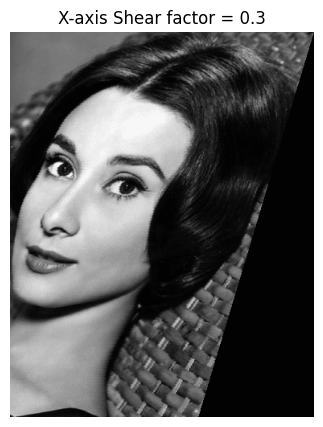

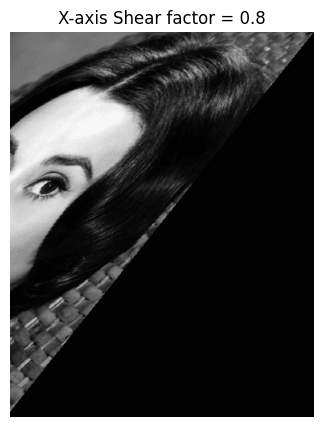

In [18]:
factors = [0.1, 0.3, 0.8]

for f in factors:
    shear_matrix = (1, f, 0,   0, 1, 0)

    sheared = img.transform(
        (width, height),
        Image.AFFINE,
        shear_matrix
    )

    plt.figure(figsize=(5,5))
    plt.imshow(sheared)
    plt.title(f"X-axis Shear factor = {f}")
    plt.axis('off')
    plt.show()

(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

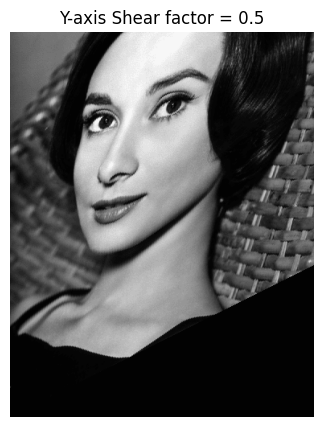

In [19]:
shear_matrix_y = (1, 0, 0, 0.5, 1, 0)

sheared_y = img.transform(
    (width, height),
    Image.AFFINE,
    shear_matrix_y
)

plt.figure(figsize=(5,5))
plt.imshow(sheared_y)
plt.title("Y-axis Shear factor = 0.5")
plt.axis('off')

(np.float64(-0.5), np.float64(566.5), np.float64(478.5), np.float64(-0.5))

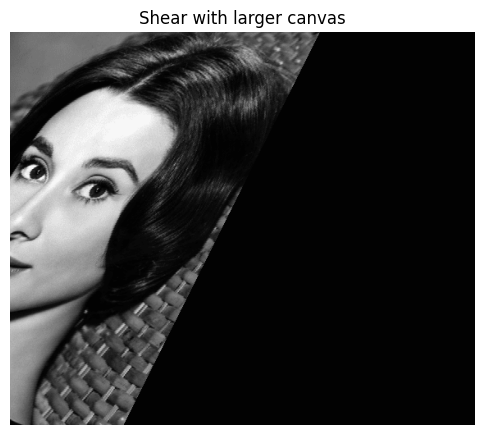

In [20]:
canvas_width = int(width * 1.5)
canvas_height = height

shear_matrix_canvas = (1, 0.5, 0, 0, 1, 0)

sheared_canvas = img.transform(
    (canvas_width, canvas_height),
    Image.AFFINE,
    shear_matrix_canvas
)

plt.figure(figsize=(6,6))
plt.imshow(sheared_canvas)
plt.title("Shear with larger canvas")
plt.axis('off')

(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

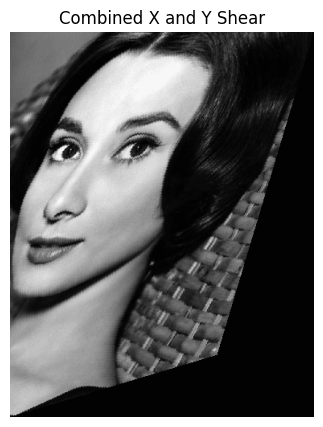

In [21]:
combined_matrix = (1, 0.3, 0, 0.3, 1, 0)

combined_shear = img.transform(
    (width, height),
    Image.AFFINE,
    combined_matrix
)

plt.figure(figsize=(5,5))
plt.imshow(combined_shear)
plt.title("Combined X and Y Shear")
plt.axis('off')

# Intensity Transformations
Negative · Log · Power Law (Gamma)

(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

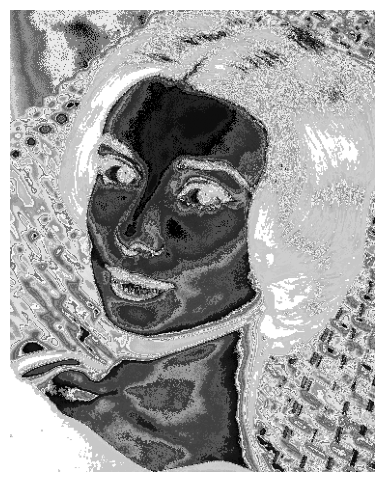

In [22]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(img)

negative = 255 - img_array

plt.figure(figsize=(6,6))
plt.imshow(negative, cmap='gray')
plt.axis('off')




In [23]:
negative_img = Image.fromarray(negative)
negative_img.save("task2_1_negative.jpg")

In [24]:
from PIL import ImageOps

(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

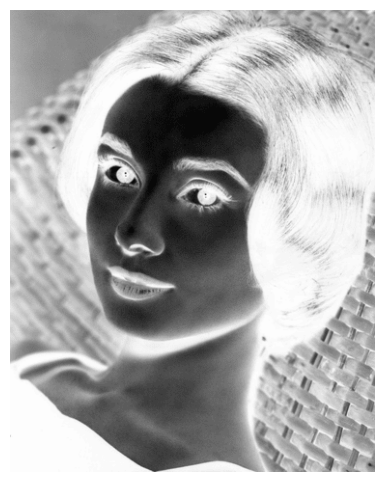

In [25]:
# Method 2: PIL's ImageOps
negative2 = ImageOps.invert(img.convert("RGB"))

plt.figure(figsize=(6,6))
plt.imshow(negative2)
plt.axis('off')


In [26]:
negative2.save("task2_2_negative_method2.jpg")

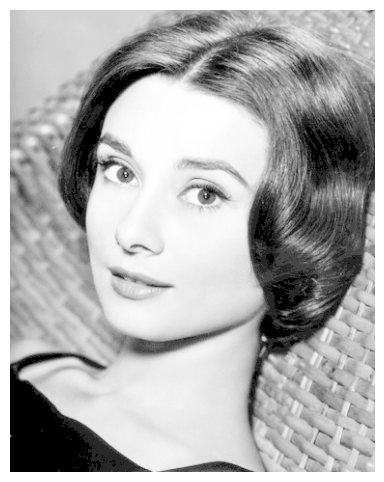

In [30]:
# ── 2. Log transformation ──────────────────────────
img_gray = np.array(img.convert("L"))

# s = c · log(1 + r) --> We need to find c.
c = 255 / np.log(1 + np.max(img_gray))
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
log_transformed = c * np.log(1 + img_gray)
log_transformed = np.array(log_transformed, dtype=np.uint8)
plt.figure(figsize=(6,6))
plt.imshow(log_transformed, cmap='gray')
plt.axis('off')
log_transformed_img = Image.fromarray(log_transformed)



# Apply the log transformation to each pixel


In [31]:
log_transformed_img.save("task2_2_log.jpg")

(np.float64(-0.5), np.float64(377.5), np.float64(478.5), np.float64(-0.5))

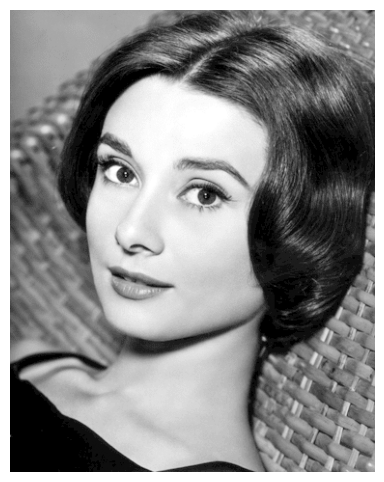

In [32]:

# ── 3. Power-law / Gamma correction ───────────────
img_gray = np.array(img.convert("L"))
gamma = 0.5
gamma_corrected = 255 * (img_gray / 255) ** gamma
gamma_corrected = np.array(gamma_corrected, dtype=np.uint8)
plt.figure(figsize=(6,6))
plt.imshow(gamma_corrected, cmap='gray')
plt.axis('off')


In [33]:
gamma_img = Image.fromarray(gamma_corrected)
gamma_img.save("task2_3_gamma.jpg")